In [3]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import plot_decomposition
from qiskit import QuantumCircuit


In [33]:
invariant_list = []
for i in trange(1000):
    qc = QuantumCircuit(2)
    qc.append(SwapGate().power(0.5), [0, 1])
    qc.append(
        UGate(
            np.random.uniform(0, 2 * np.pi),
            np.random.uniform(0, 2 * np.pi),
            np.random.uniform(0, 2 * np.pi),
        ),
        [0],
    )
    qc.append(
        UGate(
            np.random.uniform(0, 2 * np.pi),
            np.random.uniform(0, 2 * np.pi),
            np.random.uniform(0, 2 * np.pi),
        ),
        [1],
    )
    qc.append(SwapGate().power(0.5), [0, 1])
    target = GateInvariants.from_unitary(Operator(qc))
    invariant_list.append(target)

from gulps.viz.invariant_viz import scatter_plot

scatter_plot(invariant_list)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:01<00:00, 932.84it/s]


(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

Error in callback <function flush_figures at 0x7442ff2da340> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [34]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 3), 1 / 3, "sqrt3cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (SwapGate(), 0.0, "swap"),
    # (SwapGate().power(1 / 2), 1 / 2, "eswap"),
    # (SwapGate().power(1 / 3), 1 / 3, "eswap"),
]
gate_set, costs, names = zip(*isa)
isa = DiscreteISA(gate_set, costs, names, precompute_polytopes=False)
decomposer = GulpsDecomposer(isa=isa)

if hasattr(decomposer.isa, "coverage_set"):
    report = coverage_report(decomposer.isa.coverage_set)

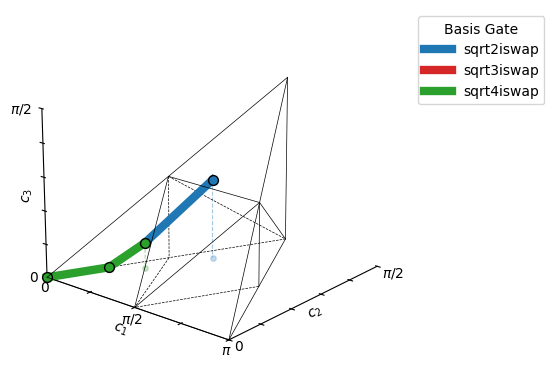

In [39]:
r = decomposer._best_decomposition(GateInvariants.from_unitary(random_unitary(4)))
fig = plot_decomposition(r.intermediates, r.sentence, isa)

In [9]:
from gulps.core.isa import ContinuousISA

isa = ContinuousISA.from_base_gate(iSwapGate(), "iswap")
isa.single_qubit_cost = 0.0
isa.k_lb = 0.0001
decomposer = GulpsDecomposer(isa=isa)

In [10]:
from collections import Counter

length_counts = Counter()
param_patterns = Counter()


def categorize_parameters(params, tol=0.005):
    """Categorize parameter patterns by uniqueness.

    Returns a pattern string like:
    - "(theta1,)" for 1 param
    - "(theta1, theta1)" for 2 identical params
    - "(theta1, theta2)" for 2 distinct params
    - "(theta1, theta1, theta1)" for 3 identical params
    - "(theta1, theta2, theta2)" for 3 params with 2 identical
    - "(theta1, theta2, theta3)" for 3 distinct params
    etc.
    """
    if not params:
        return "()"

    # Group parameters that are within tolerance
    groups = []
    for p in params:
        # Find existing group this param belongs to
        found = False
        for group in groups:
            if abs(p - group[0]) < tol:
                group.append(p)
                found = True
                break
        if not found:
            groups.append([p])

    # Sort groups by their first occurrence in params
    group_indices = []
    for group in groups:
        first_idx = min(params.index(p) for p in group if p in params)
        group_indices.append((first_idx, group))
    group_indices.sort()

    # Build pattern string
    theta_map = {}
    theta_counter = 1
    pattern_parts = []

    for p in params:
        # Find which group this param belongs to
        group_id = None
        for i, (_, group) in enumerate(group_indices):
            if any(abs(p - g) < tol for g in group):
                group_id = i
                break

        if group_id not in theta_map:
            theta_map[group_id] = f"theta{theta_counter}"
            theta_counter += 1
        pattern_parts.append(theta_map[group_id])

    return f"({', '.join(pattern_parts)})"


for i in trange(100):
    target = GateInvariants.from_unitary(random_unitary(4))
    r = decomposer._best_decomposition(target)
    length_counts[len(r.sentence)] += 1

    # Categorize parameter pattern
    pattern = categorize_parameters(r.parameters)
    param_patterns[pattern] += 1

# Display results sorted by length
print("\nSentence Length Distribution:")
for length in sorted(length_counts.keys()):
    count = length_counts[length]
    percentage = (count / 100) * 100
    print(f"Length {length}: {count} hits ({percentage:.1f}%)")

print("\nParameter Pattern Distribution:")
for pattern in sorted(param_patterns.keys(), key=lambda p: (len(p), p)):
    count = param_patterns[pattern]
    percentage = (count / 100) * 100
    print(f"{pattern}: {count} hits ({percentage:.1f}%)")

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:05<00:00, 18.60it/s]


Sentence Length Distribution:
Length 2: 81 hits (81.0%)
Length 3: 19 hits (19.0%)

Parameter Pattern Distribution:
(theta1, theta1): 35 hits (35.0%)
(theta1, theta2): 46 hits (46.0%)
(theta1, theta1, theta1): 11 hits (11.0%)
(theta1, theta1, theta2): 3 hits (3.0%)
(theta1, theta2, theta2): 4 hits (4.0%)
(theta1, theta2, theta3): 1 hits (1.0%)


In [19]:
# Collect targets grouped by parameter pattern
from collections import defaultdict

pattern_targets = defaultdict(list)
n_samples = 5000

for i in trange(n_samples, desc="Collecting targets by pattern"):
    target = GateInvariants.from_unitary(random_unitary(4))
    r = decomposer._best_decomposition(target)
    pattern = categorize_parameters(r.parameters)

    pattern_targets[pattern].append(
        {
            "target": target,
            "parameters": r.parameters,
            "sentence_length": len(r.sentence),
        }
    )

# Display pattern statistics
print("\nPattern Statistics:")
print("=" * 80)
for pattern in sorted(pattern_targets.keys(), key=lambda p: (len(p), p)):
    count = len(pattern_targets[pattern])
    percentage = (count / n_samples) * 100
    print(f"{pattern}: {count} samples ({percentage:.1f}%)")

    # Show example parameters for this pattern
    if pattern_targets[pattern]:
        ex_params = pattern_targets[pattern][0]["parameters"]
        print(f"  Example: {[f'{p:.4f}' for p in ex_params]}")
    print("-" * 40)


Pattern Statistics:
(theta1, theta1): 1938 samples (38.8%)
  Example: ['0.4126', '0.4126']
----------------------------------------
(theta1, theta2): 2008 samples (40.2%)
  Example: ['0.4877', '0.3876']
----------------------------------------
(theta1, theta1, theta1): 762 samples (15.2%)
  Example: ['0.3219', '0.3219', '0.3219']
----------------------------------------
(theta1, theta1, theta2): 51 samples (1.0%)
  Example: ['0.3598', '0.3598', '0.0604']
----------------------------------------
(theta1, theta2, theta2): 192 samples (3.8%)
  Example: ['0.4559', '0.1368', '0.1368']
----------------------------------------
(theta1, theta2, theta3): 49 samples (1.0%)
  Example: ['0.2994', '0.1475', '0.0525']
----------------------------------------



Pattern: (theta1, theta1)
Sample count: 1938


/tmp/ipykernel_2326638/48666026.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


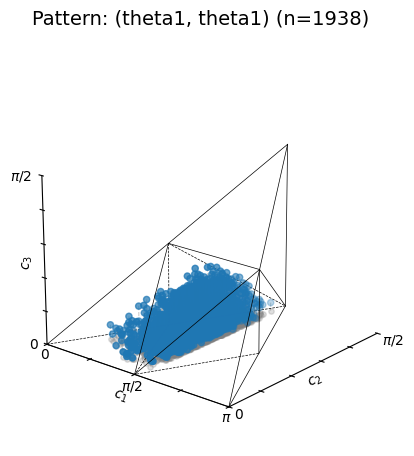


Pattern: (theta1, theta2)
Sample count: 2008


/tmp/ipykernel_2326638/48666026.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


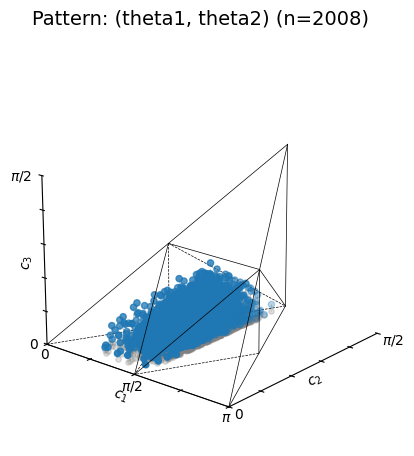


Pattern: (theta1, theta1, theta1)
Sample count: 762


/tmp/ipykernel_2326638/48666026.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


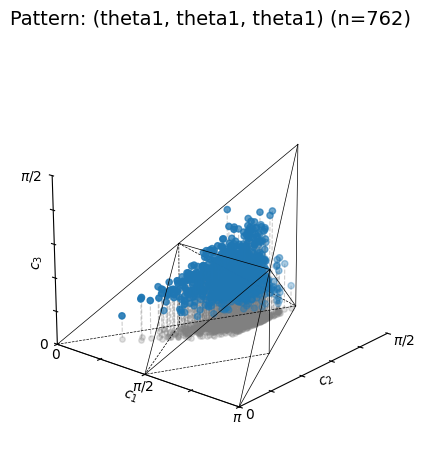


Pattern: (theta1, theta1, theta2)
Sample count: 51


/tmp/ipykernel_2326638/48666026.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


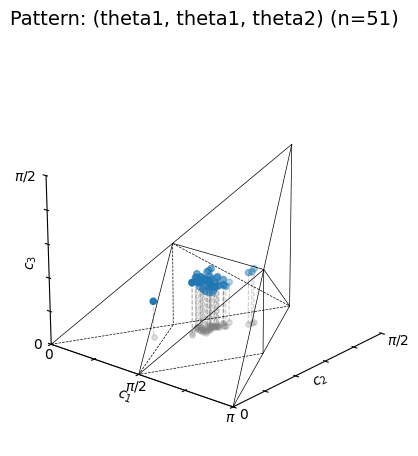


Pattern: (theta1, theta2, theta2)
Sample count: 192


/tmp/ipykernel_2326638/48666026.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


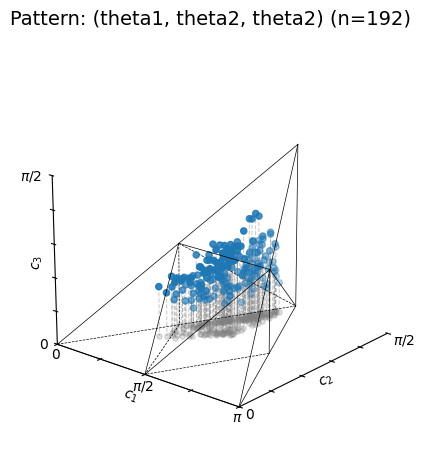


Pattern: (theta1, theta2, theta3)
Sample count: 49


/tmp/ipykernel_2326638/48666026.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


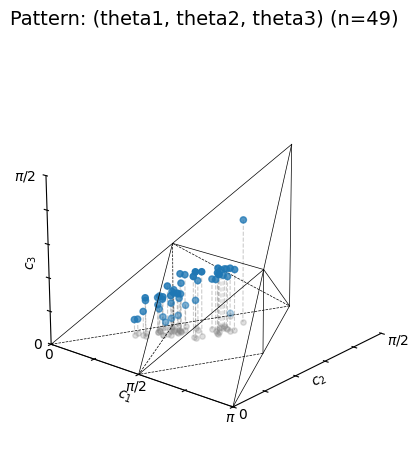

In [20]:
# Create scatter plots for each pattern category
from gulps.viz.invariant_viz import scatter_plot

for pattern in sorted(pattern_targets.keys(), key=lambda p: (len(p), p)):
    targets_in_pattern = [item["target"] for item in pattern_targets[pattern]]

    if len(targets_in_pattern) > 0:
        print(f"\n{'=' * 80}")
        print(f"Pattern: {pattern}")
        print(f"Sample count: {len(targets_in_pattern)}")
        print(f"{'=' * 80}")

        # Create scatter plot for this pattern
        fig = scatter_plot(targets_in_pattern)
        plt.suptitle(
            f"Pattern: {pattern} (n={len(targets_in_pattern)})", fontsize=14, y=1.02
        )
        plt.tight_layout()
        plt.show()


Visualizing pattern: (theta1, theta1)
Parameters: ['0.4809', '0.4809']
Sentence length: 2
Cost: 0.9618


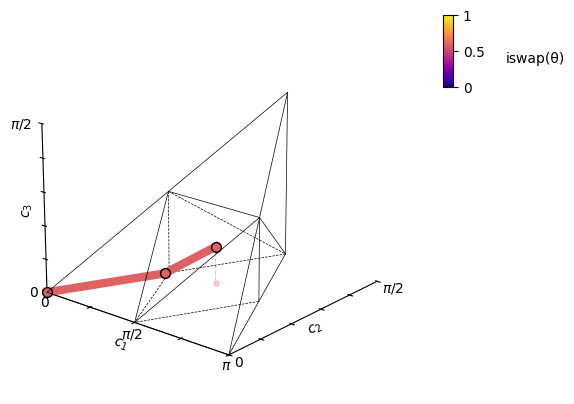


Visualizing pattern: (theta1, theta2)
Parameters: ['0.6241', '0.2653']
Sentence length: 2
Cost: 0.8894


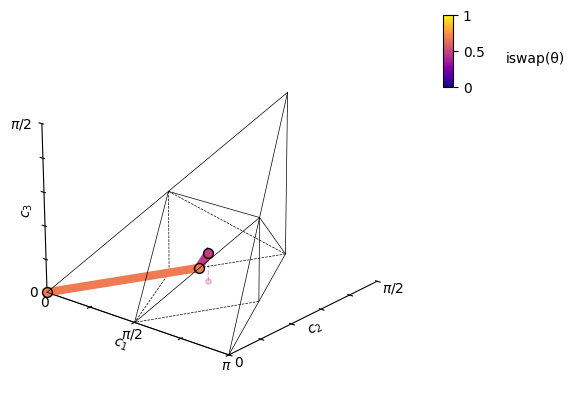


Visualizing pattern: (theta1, theta1, theta1)
Parameters: ['0.2865', '0.2865', '0.2865']
Sentence length: 3
Cost: 0.8595


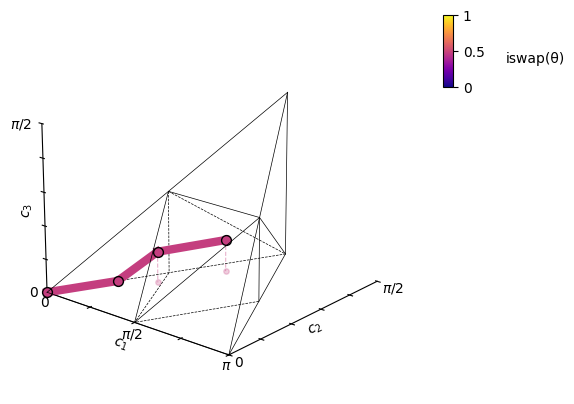

In [14]:
# Visualize examples of specific patterns you're interested in
# Change these patterns to explore different cases
patterns_to_visualize = [
    "(theta1, theta1)",
    "(theta1, theta2)",
    "(theta1, theta1, theta1)",
]

for pattern in patterns_to_visualize:
    if pattern in pattern_examples and pattern_examples[pattern]:
        print(f"\n{'=' * 80}")
        print(f"Visualizing pattern: {pattern}")
        print(f"{'=' * 80}")

        ex = pattern_examples[pattern][0]  # Take first example
        r = ex["result"]

        print(f"Parameters: {[f'{p:.4f}' for p in r.parameters]}")
        print(f"Sentence length: {len(r.sentence)}")
        print(f"Cost: {r.cost:.4f}" if r.cost else "Cost: N/A")

        # Plot the decomposition
        fig = plot_decomposition(
            r.intermediates, r.sentence, decomposer.isa, r.parameters
        )
        plt.show()
    else:
        print(f"\nNo examples found for pattern: {pattern}")

In [25]:
# Create animation and save as GIF for PowerPoint (memory-efficient)
from PIL import Image
import io

images = []
for _i in trange(100, desc="Generating frames"):
    # Generate decomposition
    r = decomposer._best_decomposition(GateInvariants.from_unitary(random_unitary(4)))
    fig = plot_decomposition(r.intermediates, r.sentence, isa, r.parameters)

    # Immediately convert to PIL Image
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    buf.seek(0)
    img = Image.open(buf).copy()
    images.append(img)
    buf.close()

    # Close the figure immediately to free memory
    plt.close(fig)

# Save as GIF
output_path = "images/trajectory_animation.gif"
images[0].save(
    output_path,
    save_all=True,
    append_images=images[1:],
    duration=150,  # milliseconds per frame
    loop=0,  # infinite loop
)

print(f"✓ Saved animation to {output_path}")
print(f"  Frames: {len(images)}, Size: {images[0].size}")

# Clean up
for img in images:
    img.close()

Generating frames:   0%|          | 0/100 [00:00<?, ?it/s]

Generating frames: 100%|██████████| 100/100 [00:22<00:00,  4.44it/s]


✓ Saved animation to images/trajectory_animation.gif
  Frames: 100, Size: (574, 404)


In [ ]:
# Create animation with space-filling walk through Weyl chamber
from PIL import Image
import io


def generate_weyl_chamber_walk(n_points=100):
    """Generate a smooth walk through the Weyl chamber triangle.

    Coordinates are normalized to [0, 0.5] as per from_weyl method.
    Constraints: x >= y >= z >= 0 (triangular region in x-y plane)

    Strategy: Sweep z from 0 to 0.5, and for each z-layer,
    traverse the triangular region x >= y >= z using a serpentine pattern.
    """
    points = []

    # Number of z-layers to traverse
    n_z_layers = max(3, int(np.ceil(n_points**0.4)))
    points_per_layer = n_points // n_z_layers

    for z_idx in range(n_z_layers):
        z = 0.5 * z_idx / max(1, n_z_layers - 1)

        # For this z-layer, traverse the triangular region x >= y >= z
        # Use sqrt to get approximately square coverage in 2D
        n_rows = max(1, int(np.ceil(np.sqrt(points_per_layer))))

        layer_points = []
        for row_idx in range(n_rows):
            # y ranges from z to some max value
            # x ranges from y to 0.5
            y_frac = row_idx / max(1, n_rows - 1)
            y = z + (0.5 - z) * y_frac

            # Number of points in this row depends on available x-range
            x_range = 0.5 - y
            if x_range > 1e-10:
                n_cols = max(1, int(np.ceil(n_rows * (x_range / (0.5 - z)))))

                for col_idx in range(n_cols):
                    x_frac = col_idx / max(1, n_cols - 1)
                    x = y + (0.5 - y) * x_frac
                    layer_points.append((x, y, z))
            else:
                layer_points.append((y, y, z))

        # Reverse every other layer for serpentine pattern
        if z_idx % 2 == 1:
            layer_points.reverse()

        points.extend(layer_points)

    # Trim to exactly n_points
    return points[:n_points]


# Generate smooth walk through Weyl chamber
weyl_points = generate_weyl_chamber_walk(n_points=500)

images = []
for i, (c1, c2, c3) in enumerate(tqdm(weyl_points, desc="Generating frames")):
    # Use from_weyl to create invariants (expects normalized coords in [0, 0.5])
    inv = GateInvariants.from_weyl((c1, c2, c3))

    # Decompose
    r = decomposer._best_decomposition(inv)
    fig = plot_decomposition(r.intermediates, r.sentence, isa)

    # Immediately convert to PIL Image
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    buf.seek(0)
    img = Image.open(buf).copy()
    images.append(img)
    buf.close()

    # Close the figure immediately to free memory
    plt.close(fig)

# Save as GIF
output_path = "images/trajectory_animation.gif"
images[0].save(
    output_path,
    save_all=True,
    append_images=images[1:],
    duration=150,  # milliseconds per frame
    loop=0,  # infinite loop
)

print(f"✓ Saved animation to {output_path}")
print(f"  Frames: {len(images)}, Size: {images[0].size}")

# Clean up
for img in images:
    img.close()

Generating frames:   0%|          | 0/343 [00:00<?, ?it/s]

Generating frames: 100%|██████████| 343/343 [00:45<00:00,  7.49it/s]


✓ Saved animation to images/trajectory_animation.gif
  Frames: 343, Size: (554, 389)
